In [2]:
print("Day 1ML setup working")

Day 1ML setup working


In [3]:
import pandas as pd
import numpy as np

print("Libraries loaded")

Libraries loaded


In [4]:
df = pd.read_csv("../data/user_dropoff.csv")
df.head()

,user_id,sessions,time_spent,dropped_off
0,1,5,120,0
1,2,2,45,1
2,3,8,300,0
3,4,1,20,1
4,5,6,200,0


In [5]:
df = pd.read_csv("../../data/user_dropoff.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../../data/user_dropoff.csv'

In [6]:
import os
os.listdir("../../data")

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../../data'

In [7]:
import os
os.listdir("../data")

['.gitkeep', 'user_dropoff.csv']

In [8]:
import pandas as pd

data = {
    "user_id": [1,2,3,4,5],
    "sessions": [5,2,8,1,6],
    "time_spent": [120,45,300,20,200],
    "dropped_off": [0,1,0,1,0]
}

df = pd.DataFrame(data)
df.to_csv("../data/user_dropoff.csv", index=False)

print("✅ Dataset created")

✅ Dataset created


In [9]:
os.listdir("../data")

['.gitkeep', 'user_dropoff.csv']

In [10]:
df = pd.read_csv("../data/user_dropoff.csv")
df.head()

,user_id,sessions,time_spent,dropped_off
0,1,5,120,0
1,2,2,45,1
2,3,8,300,0
3,4,1,20,1
4,5,6,200,0


In [11]:
df.shape

(5, 4)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      5 non-null      int64
 1   sessions     5 non-null      int64
 2   time_spent   5 non-null      int64
 3   dropped_off  5 non-null      int64
dtypes: int64(4)
memory usage: 292.0 bytes


In [13]:
df.describe()

,user_id,sessions,time_spent,dropped_off
count,5.000000,5.000000,5.000000,5.000000
mean,3.000000,4.400000,137.000000,0.400000
std,1.581139,2.880972,115.086924,0.547723
min,1.000000,1.000000,20.000000,0.000000
25%,2.000000,2.000000,45.000000,0.000000
50%,3.000000,5.000000,120.000000,0.000000
75%,4.000000,6.000000,200.000000,1.000000
max,5.000000,8.000000,300.000000,1.000000


In [14]:
df["dropped_off"].value_counts()

dropped_off
0    3
1    2
Name: count, dtype: int64

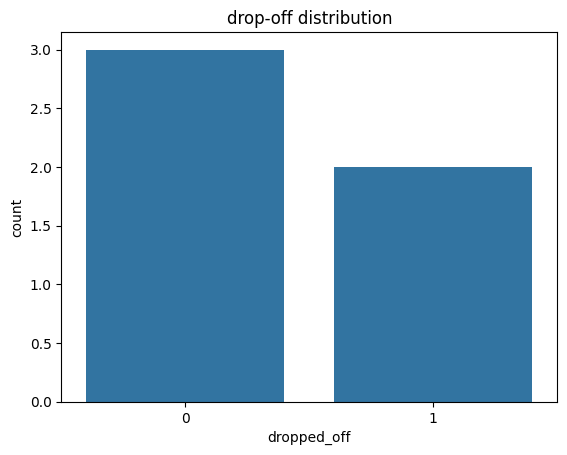

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x = "dropped_off", data = df)
plt.title("drop-off distribution")
plt.show()

In [16]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


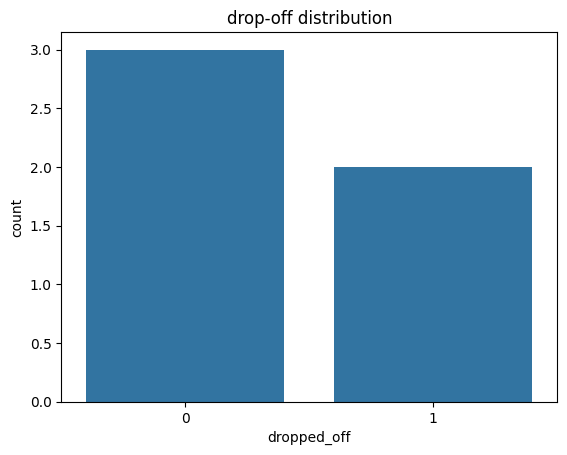

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x = "dropped_off", data = df)
plt.title("drop-off distribution")
plt.show()

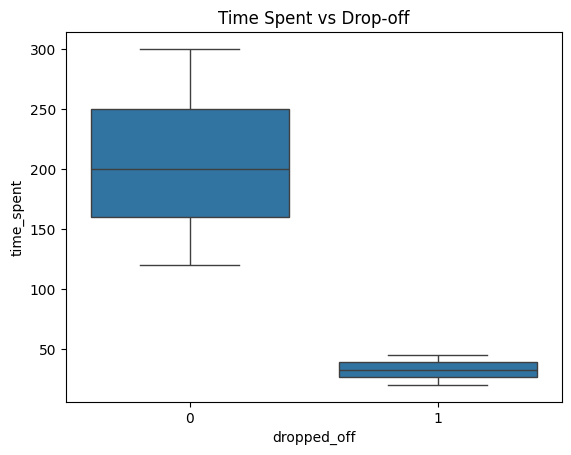

In [18]:
sns.boxplot(x="dropped_off", y="time_spent", data=df)
plt.title("Time Spent vs Drop-off")
plt.show()

In [19]:
df.corr()

,user_id,sessions,time_spent,dropped_off
user_id,1.000000,0.054882,0.185472,0.000000
sessions,0.054882,1.000000,0.977192,-0.918900
time_spent,0.185472,0.977192,1.000000,-0.828895
dropped_off,0.000000,-0.918900,-0.828895,1.000000


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [29]:
x = df[["sessions", "time_spent"]]
y = df["dropped_off"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.4, random_state = 42)
print("Data split done")

Data split done


In [30]:
model = LogisticRegression()

In [31]:
model.fit(x_train, y_train)
print("Model trained successfully")

Model trained successfully


In [32]:
y_pred = model.predict(x_test)
accuracy_score(y_test, y_pred)

1.0

In [33]:
y_pred = model.predict(x_test)
y_pred

array([1, 0])

In [34]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy", accuracy)

Accuracy 1.0


In [35]:
import joblib
import os

# create models folder if not exists
os.makedirs("../models", exist_ok=True)

# save model
joblib.dump(model, "../models/dropoff_model.pkl")

print("Model saved successfully")

Model saved successfully


In [36]:
import os
os.listdir("../models")

['.gitkeep', 'dropoff_model.pkl']

In [37]:
loaded_model = joblib.load("../models/dropoff_model.pkl")
sample = x_test.iloc[:1]
print("prediction from loaded model", loaded_model.predict(sample))

prediction from loaded model [1]
